In [2]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

16916
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [3]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]


System coefficients:
mu = 0.300
xi_x = 0.000
xi_y = 0.000

Nt: 2048
init. cond.:   0.20   0.00 




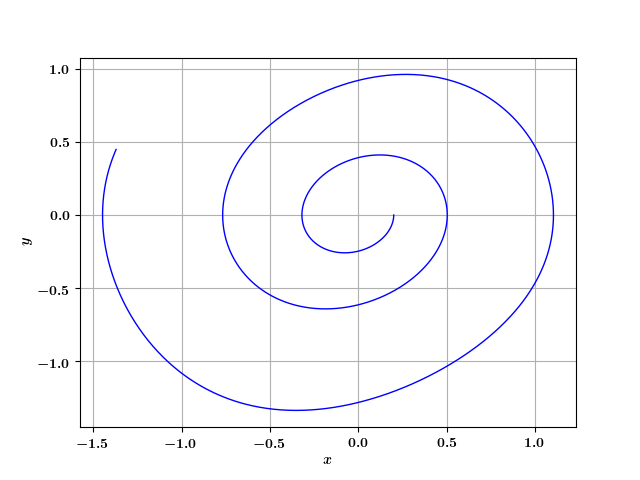

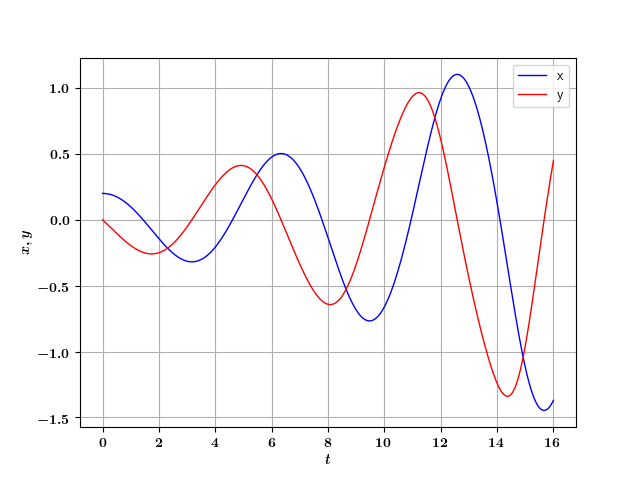

2049


In [4]:
# ---------------------------------------------------------------
# --- Van der Pol oscillator (limit cycle) ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 2  # the number of degrees of freedom
    if sel_case == 0:
        x_init = np.array([0.2, 0.0])
        tmax, nt = 16, 11

        mu, xi_x, xi_y  = 0.3, 0.0, 0.0  

        x_init -= np.array([xi_x, xi_y])
        sys_coefs = {}
        sys_coefs["mu"]   = mu
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y

        def return_sys(ss):
            mu   = ss["mu"]
            xi_x = ss["xi_x"]
            xi_y = ss["xi_y"]
            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))
            
            F_terms[0][0,0] = xi_y
            F_terms[0][1,0] = - xi_x + mu * xi_y - mu * xi_x**2 * xi_y

            F_terms[1][0, 1] = 1.
            F_terms[1][1, 0] = - (1 + 2. * mu * xi_x * xi_y)
            F_terms[1][1, 1] = mu * (1. - xi_x**2)

            F_terms[2][1, 0] = - mu * xi_y
            F_terms[2][1, 1] = - 2. * xi_x * mu

            F_terms[3][1, 1] = - mu
            return F_terms
        
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new
        
        print("\nSystem coefficients:")
        for key, value in sys_coefs.items():
            print("{:s} = {:0.3f}".format(key, value))
        print()

        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0, 1] * x[1],
            lambda x: F_terms[0][1,0] 
                + F_terms[1][1, 0] * x[0]    + F_terms[1][1, 1] * x[1] 
                + F_terms[2][1, 0] * x[0]**2 + F_terms[2][1, 1] * x[0] * x[1] 
                + F_terms[3][1, 1] * x[0]**2 * x[1]
        ]
    # ----------------------------------------------------

    return F, tmax, nt, Nx, x_init, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 0

N_nl_orig_ = 3 
F_, tmax_, nt_, Nx_, x_init_ref_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("Nt: {:d}".format(Nt_))
print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

print(len(t_ref_))

In [19]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 8
flag_max_error_ = False

# # --- Standard embedding ---
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))
# radii_emb_ = None
# case_sim_, step_t_ = "VDP", 1


# # --- Piecewise embedding ---
# zeta_th = 0.1
# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
#     x_init_ref_, N_nl, N_nl_orig_, t_, 
#     sys_coefs_, return_sys_, shift_coefs_,
#     zeta_th = zeta_th
# )
# radii_emb_ = np.full(len(t_emb_), zeta_th)
# case_sim_, step_t_ = "VDP", 1
# del zeta_th


# --- Piecewise adaptive embedding ---
flag_max_error_ = True

err_tol, zeta_max = 1.e-10, 1.0

sol_emb_, t_emb_, case_emb_, radii_emb_ = ca.solve_carleman_global_adaptive(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_init_ = zeta_max, 
    err_tolerance_ = err_tol,
    zeta_min_    = 1e-3,
    zeta_step_   = 0.02,
    zeta_thresh_ = 0.12,
    zeta_max_ = zeta_max
)
case_sim_ = "VDP_max{:0.2f}_tol{:0.3e}".format(zeta_max, err_tol)
step_t_ = 1
del err_tol, zeta_max


--- t, zeta: 1.277e+01, 1.000e+00 ---

--- t, zeta: 1.354e+01, 1.000e+00 ---

--- t, zeta: 1.428e+01, 1.000e+00 ---

--- t, zeta: 1.493e+01, 1.000e+00 ---

--- t, zeta: 1.565e+01, 1.000e+00 ---

--- t, zeta: 1.600e+01, 1.000e+00 ---
Done


write data to a file: ./jupyter-notebooks/Carleman/results//EMB_VDP_max1.00_tol1.000e-10_PAE_max_err.dat
write data to a file: ./jupyter-notebooks/Carleman/results//EMB_VDP_max1.00_tol1.000e-10_PAE_radius.dat


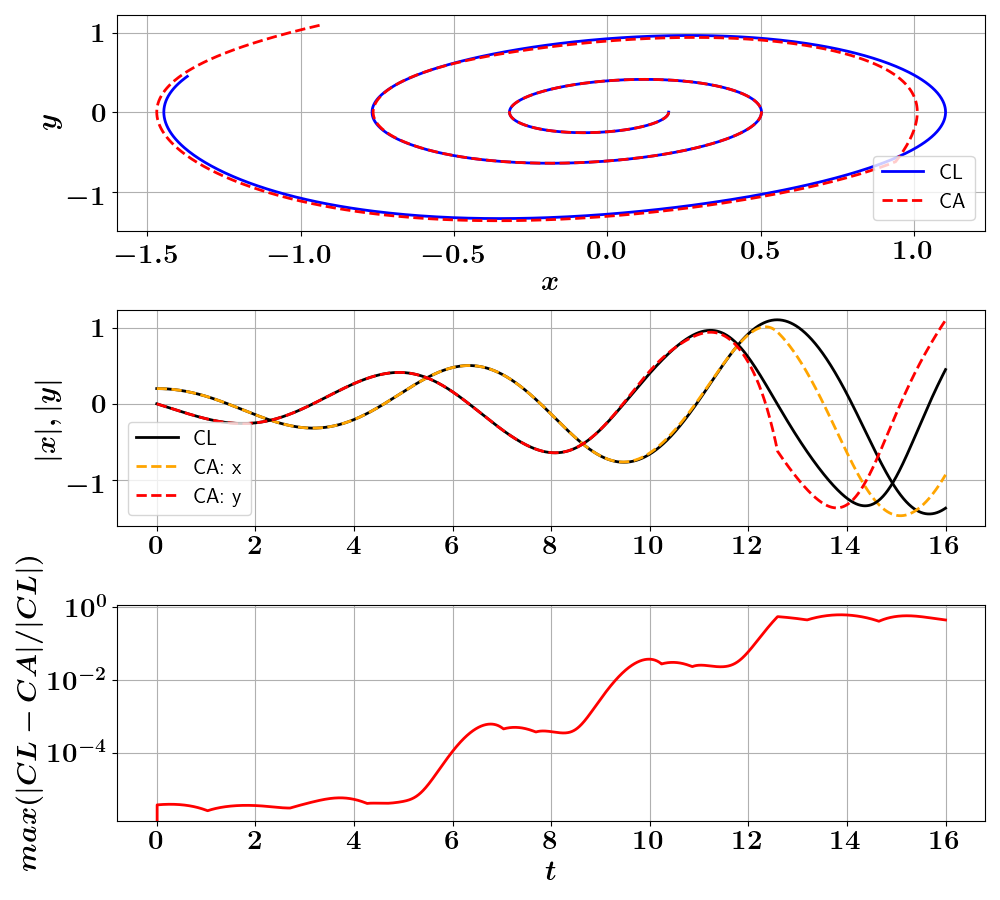

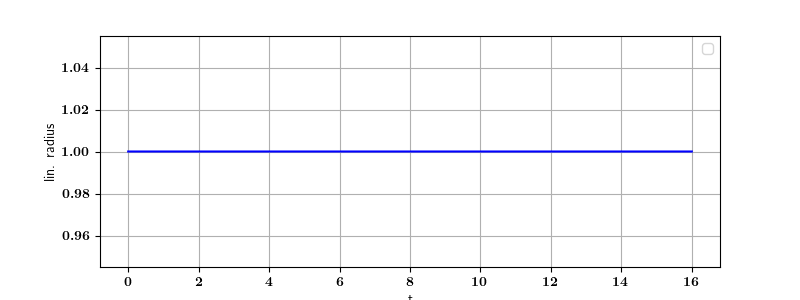

In [ ]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=False, 
    path_save=path_save_, 
    case_title = case_sim_, case_emb = case_emb_,
    fontsize = 20, fig_size = (10,9),
    radii_emb = radii_emb_,
    flag_var_semilogy = False,
    step_t = step_t_,
    flag_max_error = flag_max_error_
)